In [ ]:
import struct
import numpy as np
import os
import matplotlib.pyplot as plt
import cv2

os.makedirs("../data/balanced", exist_ok=True)
os.makedirs("../data/augmented", exist_ok=True)
os.makedirs("../data/combined", exist_ok=True)

# Utils loaders
def load_idx_images(path):
    with open(path, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows, cols)
    return images

def load_idx_labels(path):
    with open(path, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

# Utils savers
def save_images_ubyte(images, path):
    N, H, W = images.shape
    with open(path, 'wb') as f:
        f.write(struct.pack('>IIII', 2051, N, H, W))
        f.write(images.tobytes())

def save_labels_ubyte(labels, path):
    N = labels.shape[0]
    with open(path, 'wb') as f:
        f.write(struct.pack('>II', 2049, N))
        f.write(labels.tobytes())

def rotate(images):
    images = np.array([np.rot90(np.fliplr(img)) for img in images])
    return images

train_images = load_idx_images('../data/original/emnist-byclass-train-images-idx3-ubyte')
train_labels = load_idx_labels('../data/original/emnist-byclass-train-labels-idx1-ubyte')
test_images = load_idx_images('../data/original/emnist-byclass-test-images-idx3-ubyte')
test_labels = load_idx_labels('../data/original/emnist-byclass-test-labels-idx1-ubyte')

train_images = rotate(train_images)
test_images = rotate(test_images)
mapping = {}
# Digits
for i in range(10):
    mapping[i] = str(i)
# Uppercase letters
for i in range(26):
    mapping[10 + i] = chr(65 + i)
# Lowercase letters
for i in range(26):
    mapping[36 + i] = chr(97 + i)


Balancing to 5000 samples per class
Class  0 (0): train 34585 -> 5000, test  5778
Class  1 (1): train 38374 -> 5000, test  6330
Class  2 (2): train 34203 -> 5000, test  5869
Class  3 (3): train 35143 -> 5000, test  5969
Class  4 (4): train 33535 -> 5000, test  5619
Class  5 (5): train 31416 -> 5000, test  5190
Class  6 (6): train 34232 -> 5000, test  5705
Class  7 (7): train 35754 -> 5000, test  6139
Class  8 (8): train 33946 -> 5000, test  5633
Class  9 (9): train 33847 -> 5000, test  5686
Class 10 (A): train  6407 -> 5000, test  1062
Class 11 (B): train  3878 -> 5000, test   648
Class 12 (C): train 10094 -> 5000, test  1739
Class 13 (D): train  4562 -> 5000, test   779
Class 14 (E): train  4934 -> 5000, test   851
Class 15 (F): train  9182 -> 5000, test  1440
Class 16 (G): train  2517 -> 5000, test   447
Class 17 (H): train  3152 -> 5000, test   521
Class 18 (I): train 11946 -> 5000, test  2048
Class 19 (J): train  3762 -> 5000, test   626
Class 20 (K): train  2468 -> 5000, test   3

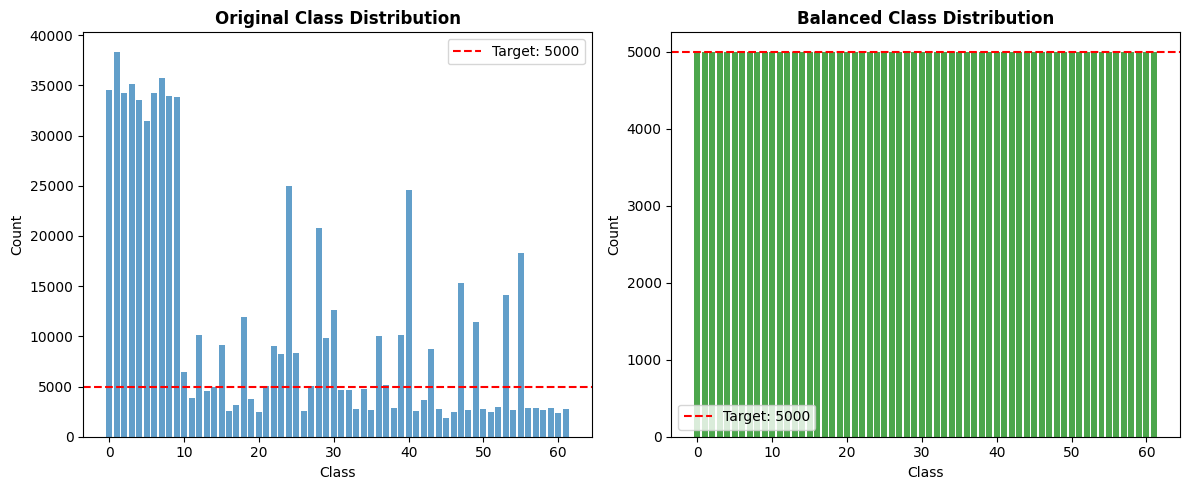

In [26]:
balanced_target = 5000
print(f"\nBalancing to {balanced_target} samples per class")

train_images_balanced = []
train_labels_balanced = []
test_images_balanced = []
test_labels_balanced = []

for cls in range(62):
    # Handle training data
    cls_train_indices = np.where(train_labels == cls)[0]
    cls_train_images = train_images[cls_train_indices]
    count = len(cls_train_indices)
    
    if count >= balanced_target:
        # Undersample
        selected = np.random.choice(cls_train_indices, balanced_target, replace=False)
        train_images_balanced.append(train_images[selected])
        train_labels_balanced.append(train_labels[selected])
    else:
        # Oversample
        train_images_balanced.append(cls_train_images)
        train_labels_balanced.append(train_labels[cls_train_indices])
        
        # Duplicate samples 
        needed = balanced_target - count
        duplicate_indices = np.random.choice(cls_train_indices, needed, replace=True)
        train_images_balanced.append(train_images[duplicate_indices])
        train_labels_balanced.append(train_labels[duplicate_indices])
    
    # Handle test data 
    cls_test_indices = np.where(test_labels == cls)[0]
    test_images_balanced.append(test_images[cls_test_indices])
    test_labels_balanced.append(test_labels[cls_test_indices])
    
    print(f"Class {cls:2d} ({mapping[cls]}): train {count:5d} -> {balanced_target}, test {len(cls_test_indices):5d}")

# Concatenate all data
train_images_balanced = np.concatenate(train_images_balanced, axis=0)
train_labels_balanced = np.concatenate(train_labels_balanced, axis=0)
test_images_balanced = np.concatenate(test_images_balanced, axis=0)
test_labels_balanced = np.concatenate(test_labels_balanced, axis=0)

# Shuffle
shuffle_idx = np.random.permutation(len(train_images_balanced))
train_images_balanced = train_images_balanced[shuffle_idx]
train_labels_balanced = train_labels_balanced[shuffle_idx]

print(f"Train: {train_images_balanced.shape}")
print(f"Test: {test_images_balanced.shape}")

# Plot distribution
original_counts = [np.sum(train_labels == i) for i in range(62)]
balanced_counts = [np.sum(train_labels_balanced == i) for i in range(62)]

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.bar(range(62), original_counts, alpha=0.7)
plt.title("Original Class Distribution", fontweight='bold')
plt.xlabel("Class")
plt.ylabel("Count")
plt.axhline(y=balanced_target, color='r', linestyle='--', label=f'Target: {balanced_target}')
plt.legend()

plt.subplot(1,2,2)
plt.bar(range(62), balanced_counts, alpha=0.7, color='green')
plt.title("Balanced Class Distribution", fontweight='bold')
plt.xlabel("Class")
plt.ylabel("Count")
plt.axhline(y=balanced_target, color='r', linestyle='--', label=f'Target: {balanced_target}')
plt.legend()
plt.tight_layout()
plt.show()

save_images_ubyte(train_images_balanced, "../data/balanced/emnist-byclass-train-images-idx3-ubyte")
save_labels_ubyte(train_labels_balanced, "../data/balanced/emnist-byclass-train-labels-idx1-ubyte")
save_images_ubyte(test_images_balanced, "../data/balanced/emnist-byclass-test-images-idx3-ubyte")
save_labels_ubyte(test_labels_balanced, "../data/balanced/emnist-byclass-test-labels-idx1-ubyte")


Augmenting to 5000 samples per class
Class  0 (0): train 34585 -> 34585
Class  1 (1): train 38374 -> 38374
Class  2 (2): train 34203 -> 34203
Class  3 (3): train 35143 -> 35143
Class  4 (4): train 33535 -> 33535
Class  5 (5): train 31416 -> 31416
Class  6 (6): train 34232 -> 34232
Class  7 (7): train 35754 -> 35754
Class  8 (8): train 33946 -> 33946
Class  9 (9): train 33847 -> 33847
Class 10 (A): train  6407 -> 6407
Class 11 (B): train  3878 -> 5000
Class 12 (C): train 10094 -> 10094
Class 13 (D): train  4562 -> 5000
Class 14 (E): train  4934 -> 5000
Class 15 (F): train  9182 -> 9182
Class 16 (G): train  2517 -> 5000
Class 17 (H): train  3152 -> 5000
Class 18 (I): train 11946 -> 11946
Class 19 (J): train  3762 -> 5000
Class 20 (K): train  2468 -> 5000
Class 21 (L): train  5076 -> 5076
Class 22 (M): train  9002 -> 9002
Class 23 (N): train  8237 -> 8237
Class 24 (O): train 24983 -> 24983
Class 25 (P): train  8347 -> 8347
Class 26 (Q): train  2605 -> 5000
Class 27 (R): train  5073 -> 50

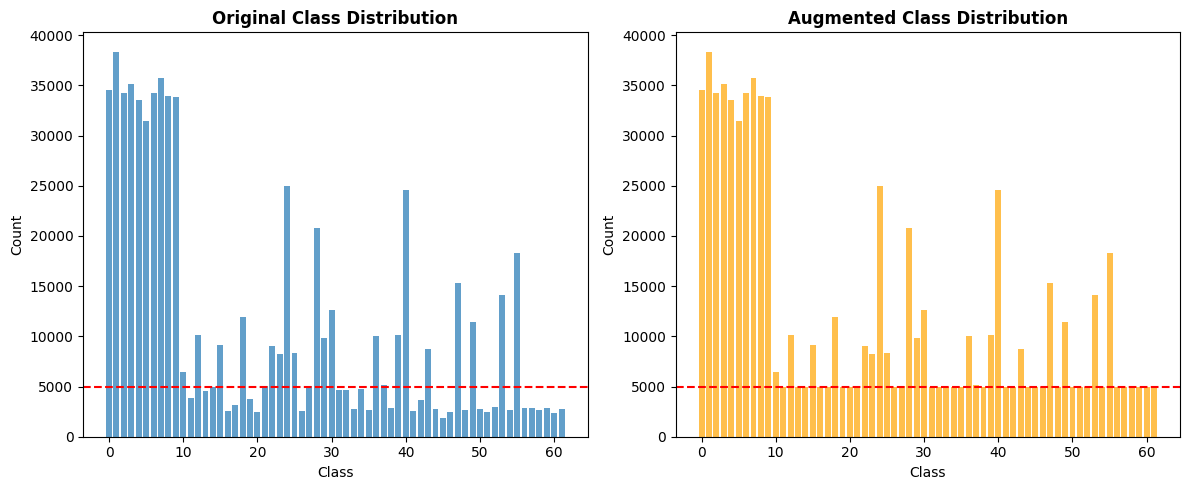

In [30]:
def augment_image(img):
    img = img.astype(np.float32)

    # Rotate
    angle = np.random.uniform(-12, 12)
    M = cv2.getRotationMatrix2D((14, 14), angle, 1.0)
    img = cv2.warpAffine(img, M, (28, 28), borderValue=0)

    # Shift
    tx = np.random.uniform(-2, 2)
    ty = np.random.uniform(-2, 2)
    M = np.float32([[1, 0, tx], [0, 1, ty]])
    img = cv2.warpAffine(img, M, (28, 28), borderValue=0)

    # Gaussian noise
    noise = np.random.normal(0, 8, img.shape)
    img = img + noise

    return np.clip(img, 0, 255).astype(np.uint8)

balanced_target = 5000
print(f"\nAugmenting to {balanced_target} samples per class")

train_images_aug = []
train_labels_aug = []
test_images_aug = []
test_labels_aug = []

for cls in range(62):
    cls_train_indices = np.where(train_labels == cls)[0]
    cls_train_images = train_images[cls_train_indices]
    count = len(cls_train_images)

    train_images_aug.append(cls_train_images)
    train_labels_aug.append(train_labels[cls_train_indices])

    if count < balanced_target:
        needed = balanced_target - count
        aug_imgs = np.zeros((needed, 28, 28), dtype=np.uint8)
        aug_labels = np.full(needed, cls, dtype=np.uint8)

        for i in range(needed):
            idx = np.random.randint(0, count)
            aug_imgs[i] = augment_image(cls_train_images[idx])

        train_images_aug.append(aug_imgs)
        train_labels_aug.append(aug_labels)

    cls_test_indices = np.where(test_labels == cls)[0]
    test_images_aug.append(test_images[cls_test_indices])
    test_labels_aug.append(test_labels[cls_test_indices])

    print(f"Class {cls:2d} ({mapping[cls]}): train {count:5d} -> {max(count, balanced_target)}, test {len(cls_test_indices):5d}")

train_images_aug = np.concatenate(train_images_aug, axis=0)
train_labels_aug = np.concatenate(train_labels_aug, axis=0)
test_images_aug = np.concatenate(test_images_aug, axis=0)
test_labels_aug = np.concatenate(test_labels_aug, axis=0)

shuffle_idx = np.random.permutation(len(train_images_aug))
train_images_aug = train_images_aug[shuffle_idx]
train_labels_aug = train_labels_aug[shuffle_idx]

print(f"\nTrain shape: {train_images_aug.shape}")
print(f"Test shape : {test_images_aug.shape}")

original_counts = [np.sum(train_labels == i) for i in range(62)]
aug_counts = [np.sum(train_labels_aug == i) for i in range(62)]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(range(62), original_counts, alpha=0.7)
plt.title("Original Class Distribution", fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Count")
plt.axhline(y=balanced_target, color="r", linestyle="--")

plt.subplot(1,2,2)
plt.bar(range(62), aug_counts, alpha=0.7, color="orange")
plt.title("Augmented Class Distribution", fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Count")
plt.axhline(y=balanced_target, color="r", linestyle="--")

plt.tight_layout()
plt.show()

save_images_ubyte(train_images_aug, "../data/augmented//emnist-byclass-train-images-idx3-ubyte")
save_labels_ubyte(train_labels_aug, "../data/augmented/emnist-byclass-train-labels-idx1-ubyte")
save_images_ubyte(test_images_aug, "../data/augmented/emnist-byclass-test-images-idx3-ubyte")
save_labels_ubyte(test_labels_aug, "../data/augmented/emnist-byclass-test-labels-idx1-ubyte")


Balancing + Augmenting to 5000 samples per class
Class  0 (0): train 34585 ->  5000, test  5778
Class  1 (1): train 38374 ->  5000, test  6330
Class  2 (2): train 34203 ->  5000, test  5869
Class  3 (3): train 35143 ->  5000, test  5969
Class  4 (4): train 33535 ->  5000, test  5619
Class  5 (5): train 31416 ->  5000, test  5190
Class  6 (6): train 34232 ->  5000, test  5705
Class  7 (7): train 35754 ->  5000, test  6139
Class  8 (8): train 33946 ->  5000, test  5633
Class  9 (9): train 33847 ->  5000, test  5686
Class 10 (A): train  6407 ->  5000, test  1062
Class 11 (B): train  3878 ->  5000, test   648
Class 12 (C): train 10094 ->  5000, test  1739
Class 13 (D): train  4562 ->  5000, test   779
Class 14 (E): train  4934 ->  5000, test   851
Class 15 (F): train  9182 ->  5000, test  1440
Class 16 (G): train  2517 ->  5000, test   447
Class 17 (H): train  3152 ->  5000, test   521
Class 18 (I): train 11946 ->  5000, test  2048
Class 19 (J): train  3762 ->  5000, test   626
Class 20 (

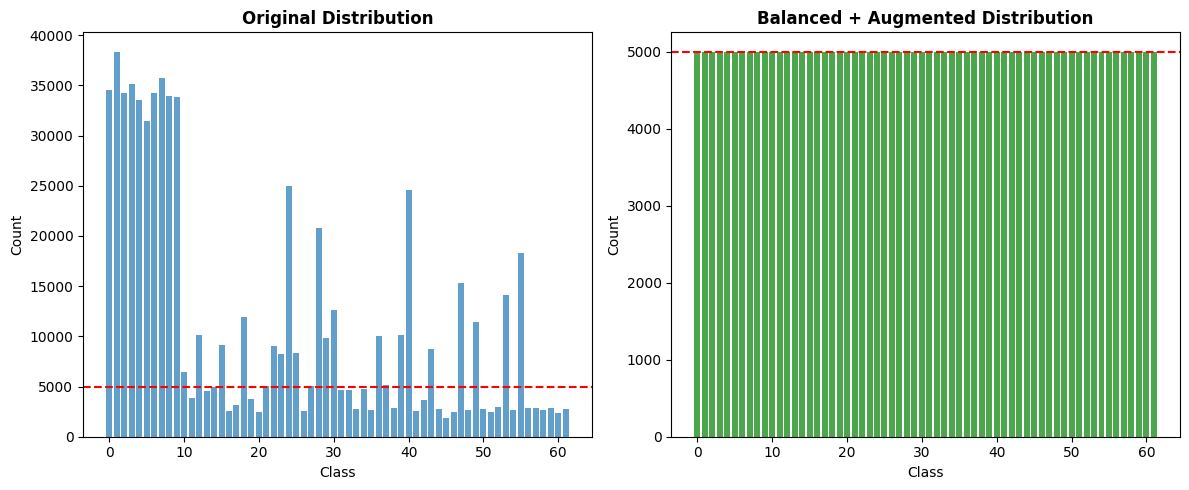

In [28]:
print(f"\nBalancing + Augmenting to {balanced_target} samples per class")
balanced_target = 5000

train_images_final = []
train_labels_final = []
test_images_final = []
test_labels_final = []

for cls in range(62):
    cls_train_indices = np.where(train_labels == cls)[0]
    cls_train_images = train_images[cls_train_indices]
    count = len(cls_train_images)

    if count > balanced_target:
        selected_idx = np.random.choice(count, balanced_target, replace=False)
        train_images_final.append(cls_train_images[selected_idx])
        train_labels_final.append(np.full(balanced_target, cls, dtype=np.uint8))
        final_count = balanced_target

    elif count < balanced_target:
        needed = balanced_target - count

        aug_imgs = np.zeros((needed, 28, 28), dtype=np.uint8)
        for i in range(needed):
            idx = np.random.randint(0, count)
            aug_imgs[i] = augment_image(cls_train_images[idx])

        train_images_final.append(cls_train_images)
        train_labels_final.append(np.full(count, cls, dtype=np.uint8))

        train_images_final.append(aug_imgs)
        train_labels_final.append(np.full(needed, cls, dtype=np.uint8))
        final_count = balanced_target

    else:
        train_images_final.append(cls_train_images)
        train_labels_final.append(np.full(count, cls, dtype=np.uint8))
        final_count = count

    cls_test_indices = np.where(test_labels == cls)[0]
    test_images_final.append(test_images[cls_test_indices])
    test_labels_final.append(test_labels[cls_test_indices])

    print(f"Class {cls:2d} ({mapping[cls]}): train {count:5d} -> {final_count:5d}, test {len(cls_test_indices):5d}")

train_images_final = np.concatenate(train_images_final, axis=0)
train_labels_final = np.concatenate(train_labels_final, axis=0)
test_images_final = np.concatenate(test_images_final, axis=0)
test_labels_final = np.concatenate(test_labels_final, axis=0)

shuffle_idx = np.random.permutation(len(train_images_final))
train_images_final = train_images_final[shuffle_idx]
train_labels_final = train_labels_final[shuffle_idx]

print(f"\nFinal Train shape: {train_images_final.shape}")
print(f"Final Test  shape: {test_images_final.shape}")

original_counts = [np.sum(train_labels == i) for i in range(62)]
final_counts = [np.sum(train_labels_final == i) for i in range(62)]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(range(62), original_counts, alpha=0.7)
plt.title("Original Distribution", fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Count")
plt.axhline(y=balanced_target, color="r", linestyle="--")

plt.subplot(1,2,2)
plt.bar(range(62), final_counts, alpha=0.7, color="green")
plt.title("Balanced + Augmented Distribution", fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Count")
plt.axhline(y=balanced_target, color="r", linestyle="--")

plt.tight_layout()
plt.show()

save_images_ubyte(
    train_images_final,
    "../data/combined/emnist-byclass-train-images-idx3-ubyte"
)
save_labels_ubyte(
    train_labels_final,
    "../data/combined/emnist-byclass-train-labels-idx1-ubyte"
)
save_images_ubyte(
    test_images_final,
    "../data/combined/emnist-byclass-test-images-idx3-ubyte"
)
save_labels_ubyte(test_labels_final,"../data/combined/emnist-byclass-test-labels-idx1-ubyte")

In [29]:
import zipfile

# Zip folder
base_dir = "../data"
folders_to_zip = ["original", "balanced", "augmented", "combined"]

for folder in folders_to_zip:
    folder_path = os.path.join(base_dir, folder)
    zip_path = os.path.join(base_dir, f"{folder}.zip")  
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, base_dir)
                zipf.write(file_path, arcname)
    print(f"Zip created at '{zip_path}'")


Zip created at '../data\original.zip'
Zip created at '../data\balanced.zip'
Zip created at '../data\augmented.zip'
Zip created at '../data\combined.zip'
